
# PROJET SUPERVISÉ : PRÉDICTION DE LA QUALITÉ DU VIN ROUGE
# Classification binaire + Régression



## 1. Import des bibliothèques

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_squared_error, r2_score, roc_curve, auc)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

## 2. Chargement du dataset (fichier local dans `archive/`)

In [25]:

df = pd.read_csv('archive/winequality-red.csv')   

print(" Dataset chargé")
print(f"Dimensions : {df.shape}")
print("\nAperçu des 5 premières lignes :")
print(df.head())

 Dataset chargé
Dimensions : (1599, 12)

Aperçu des 5 premières lignes :
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  q

## 3. Exploration visuelle rapide

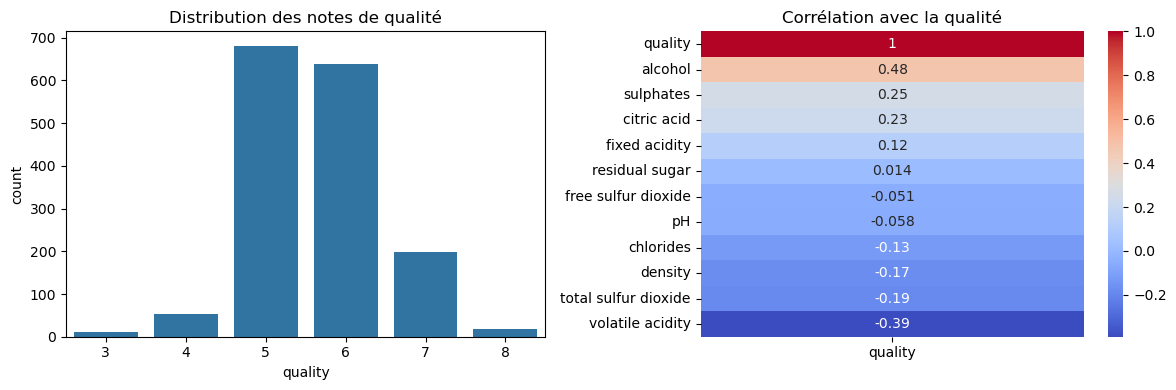

In [26]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.countplot(x='quality', data=df)
plt.title("Distribution des notes de qualité")
plt.subplot(1,2,2)
sns.heatmap(df.corr()[['quality']].sort_values(by='quality', ascending=False), annot=True, cmap='coolwarm')
plt.title("Corrélation avec la qualité")
plt.tight_layout()
plt.show()

## 3bis. Analyse détaillée des distributions et outliers

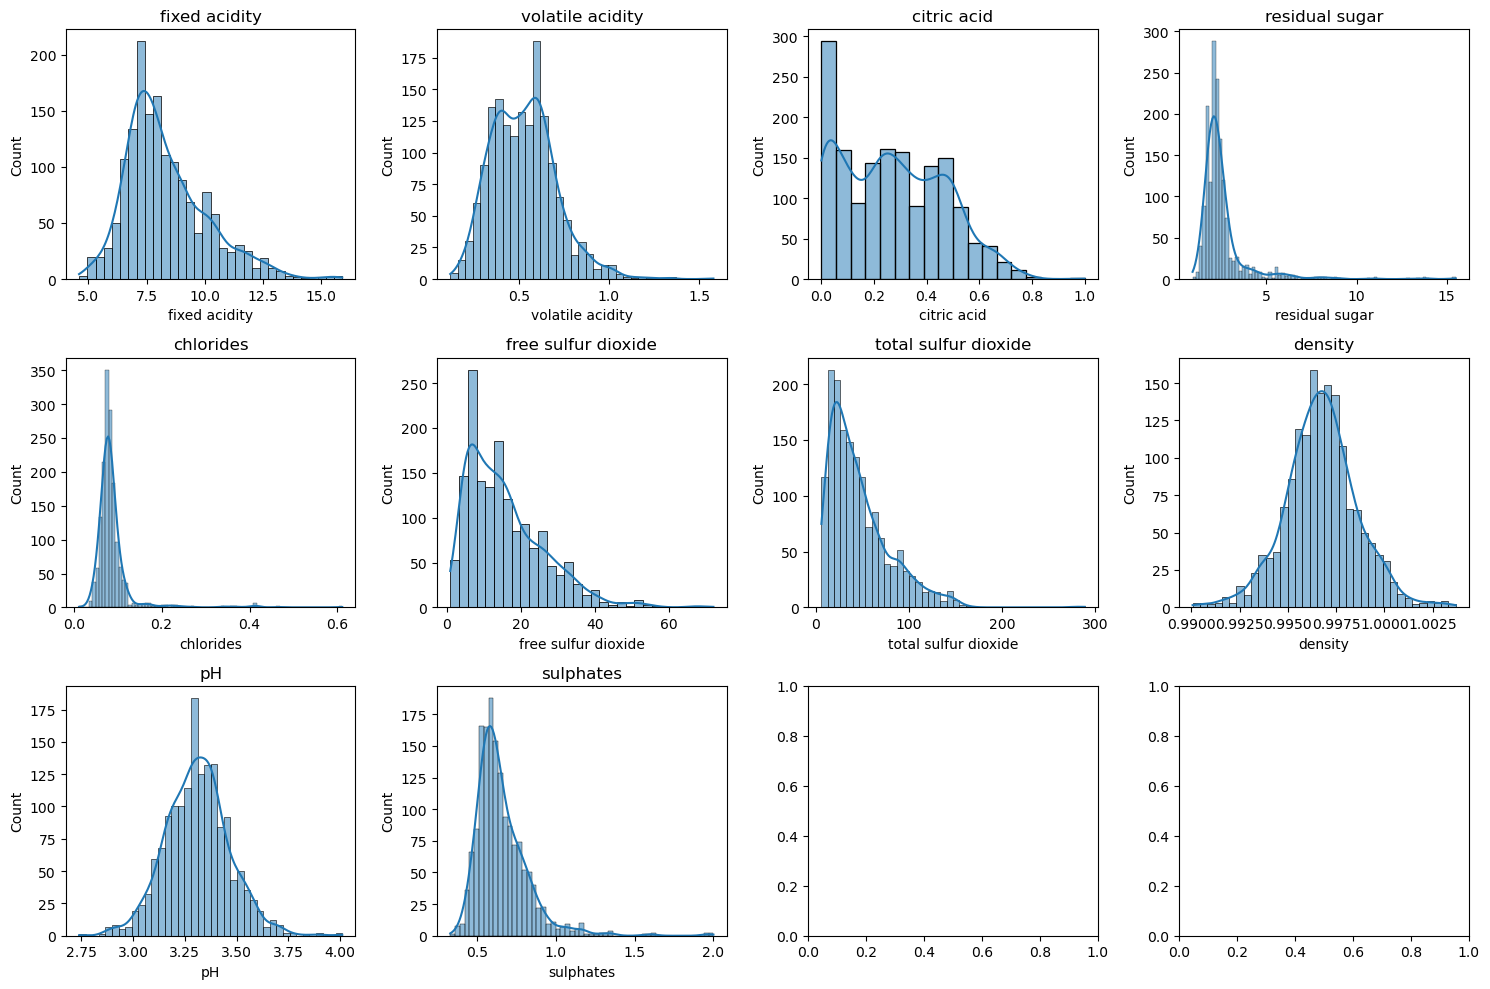

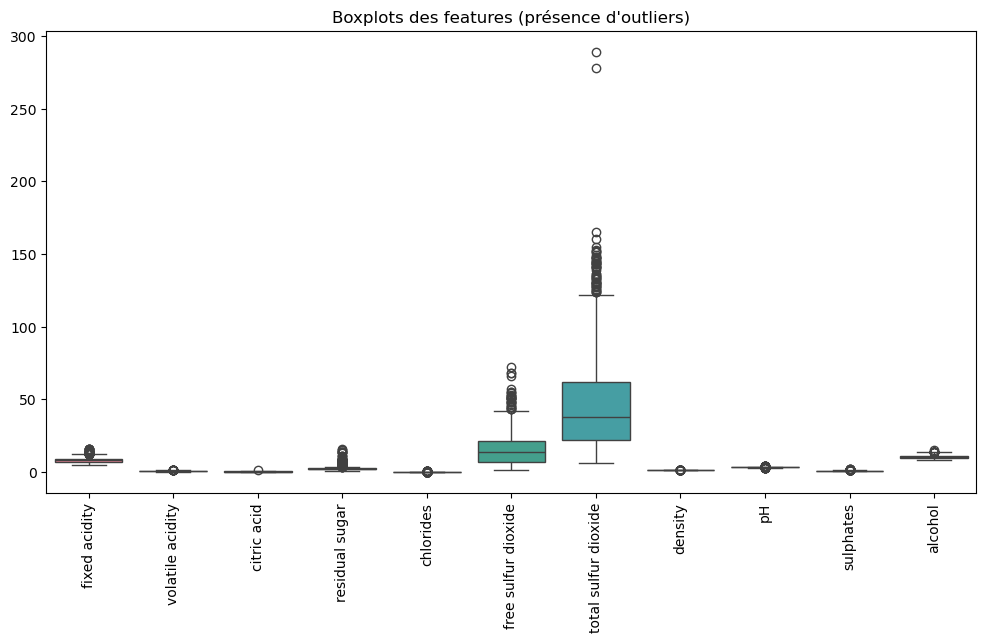

In [27]:
# Distribution des features
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(df.columns[:-2]):  # on exclut quality et good_wine (pas encore créé)
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Boîtes à moustaches (outliers)
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop(columns=['quality']))
plt.xticks(rotation=90)
plt.title("Boxplots des features (présence d'outliers)")
plt.show()

## 4. Préparation des données (cible binaire, features, normalisation, split)

In [28]:
# Création de la cible binaire (bon vin = qualité >= 7)
df['good_wine'] = (df['quality'] >= 7).astype(int)

# Séparation features / cibles
X = df.drop(['quality', 'good_wine'], axis=1)
y_class = df['good_wine']      # classification
y_reg = df['quality']           # régression

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Division train/test (70% / 30%)
X_train, X_test, y_train_class, y_test_class = train_test_split(X_scaled, y_class, test_size=0.3, random_state=42)
_, _, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.3, random_state=42)

print(f"Train size : {X_train.shape[0]}, Test size : {X_test.shape[0]}")
print("Répartition des classes :", y_class.value_counts().to_dict())

Train size : 1119, Test size : 480
Répartition des classes : {0: 1382, 1: 217}


## 4bis. Vérification de l’équilibre des classes

In [29]:
print("Distribution des classes :")
print(y_class.value_counts())
print(f"Proportion de bons vins : {y_class.mean()*100:.2f}%")

Distribution des classes :
good_wine
0    1382
1     217
Name: count, dtype: int64
Proportion de bons vins : 13.57%


## 5. Classification binaire – Comparaison de 6 modèles


--- Régression Logistique ---
Accuracy : 0.8646
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       413
           1       0.53      0.30      0.38        67

    accuracy                           0.86       480
   macro avg       0.71      0.63      0.65       480
weighted avg       0.84      0.86      0.85       480

Matrice de confusion :
 [[395  18]
 [ 47  20]]

--- KNN (k=5) ---
Accuracy : 0.8708
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       413
           1       0.55      0.45      0.49        67

    accuracy                           0.87       480
   macro avg       0.73      0.69      0.71       480
weighted avg       0.86      0.87      0.87       480

Matrice de confusion :
 [[388  25]
 [ 37  30]]

--- Arbre de décision (depth=4) ---
Accuracy : 0.8667
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       413
  

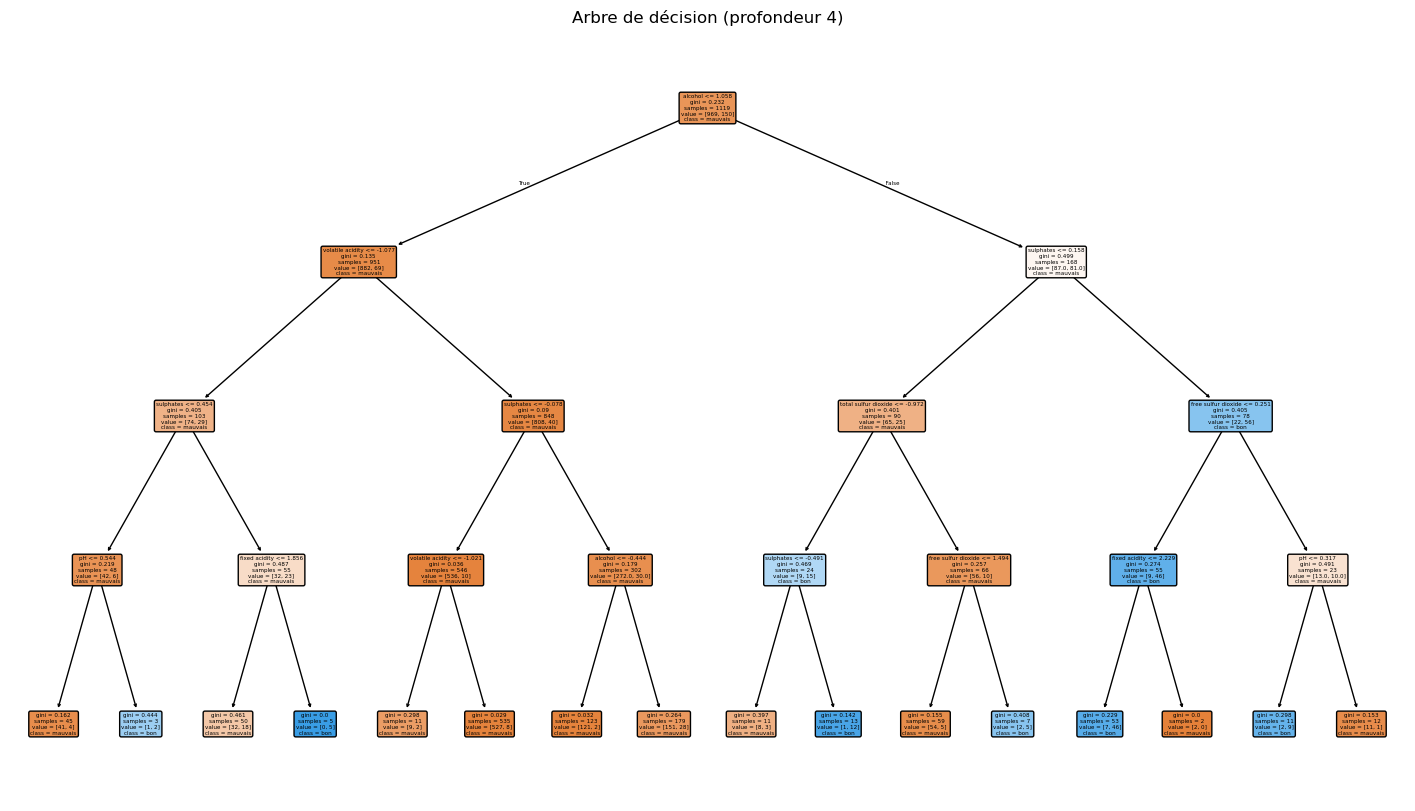


--- Forêt Aléatoire (100 arbres) ---
Accuracy : 0.8875
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       413
           1       0.62      0.49      0.55        67

    accuracy                           0.89       480
   macro avg       0.77      0.72      0.74       480
weighted avg       0.88      0.89      0.88       480

Matrice de confusion :
 [[393  20]
 [ 34  33]]

--- AdaBoost (50) ---
Accuracy : 0.8562
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       413
           1       0.48      0.34      0.40        67

    accuracy                           0.86       480
   macro avg       0.69      0.64      0.66       480
weighted avg       0.84      0.86      0.85       480

Matrice de confusion :
 [[388  25]
 [ 44  23]]

--- Gradient Boosting ---
Accuracy : 0.8625
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       413
 

In [30]:
models_class = {
    'Régression Logistique': LogisticRegression(max_iter=1000),
    'KNN (k=5)': KNeighborsClassifier(),
    'Arbre de décision (depth=4)': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Forêt Aléatoire (100 arbres)': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost (50)': AdaBoostClassifier(n_estimators=50, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results_class = {}

for name, model in models_class.items():
    model.fit(X_train, y_train_class)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_class, y_pred)
    results_class[name] = acc
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(classification_report(y_test_class, y_pred))
    print("Matrice de confusion :\n", confusion_matrix(y_test_class, y_pred))
    
    # Pour l'arbre, afficher les règles
    if name == 'Arbre de décision (depth=4)':
        rules = export_text(model, feature_names=list(X.columns))
        print("\nRègles extraites :\n", rules[:800])
        plt.figure(figsize=(18,10))
        plot_tree(model, feature_names=X.columns, class_names=['mauvais','bon'], filled=True, rounded=True)
        plt.title("Arbre de décision (profondeur 4)")
        plt.show()


## 5bis. Temps d’exécution des modèles

In [35]:
from sklearn.model_selection import train_test_split

# 1. Séparer X et y
X = df.drop("quality", axis=1)
y = df["quality"]

# 2. Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
import time

train_times = {}
predict_times = {}

# modèle
model.fit(X_train, y_train)

start = time.time()
model.fit(X_train, y_train)
train_times["Decision Tree"] = time.time() - start

start = time.time()
y_pred = model.predict(X_test)
predict_times["Decision Tree"] = time.time() - start

print(train_times)
print(predict_times)

{'Decision Tree': 2.4114723205566406}
{'Decision Tree': 0.010214090347290039}


## 6. Graphique comparatif des accuracies

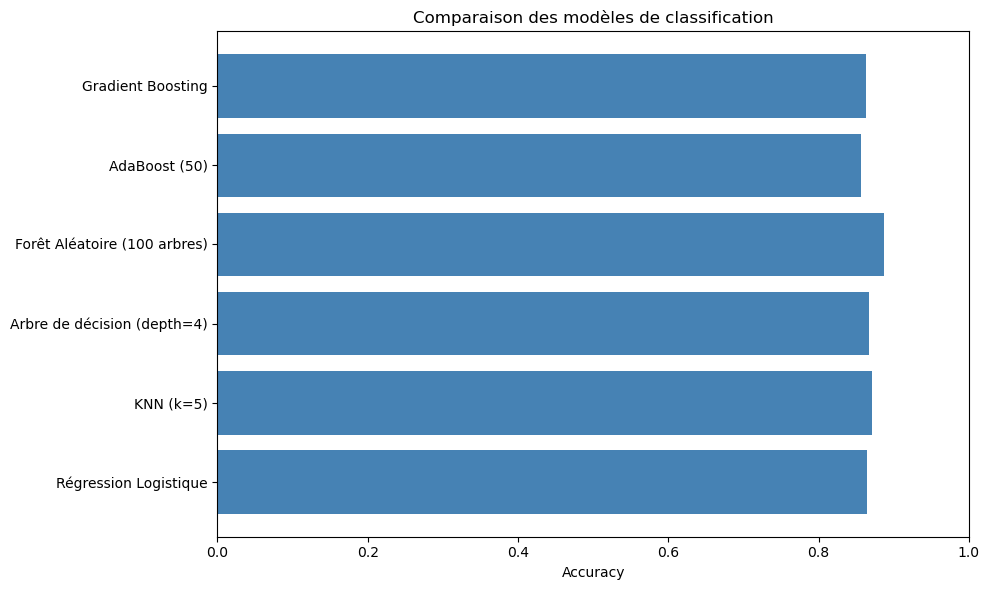

In [13]:
plt.figure(figsize=(10,6))
plt.barh(list(results_class.keys()), list(results_class.values()), color='steelblue')
plt.xlabel("Accuracy")
plt.title("Comparaison des modèles de classification")
plt.xlim(0,1)
plt.tight_layout()
plt.show()

## 7. Validation croisée et courbe d’apprentissage (biais/variance)

Validation croisée 5 folds : [0.878125   0.825      0.875      0.859375   0.87460815]
Moyenne : 0.8624 +/- 0.0198


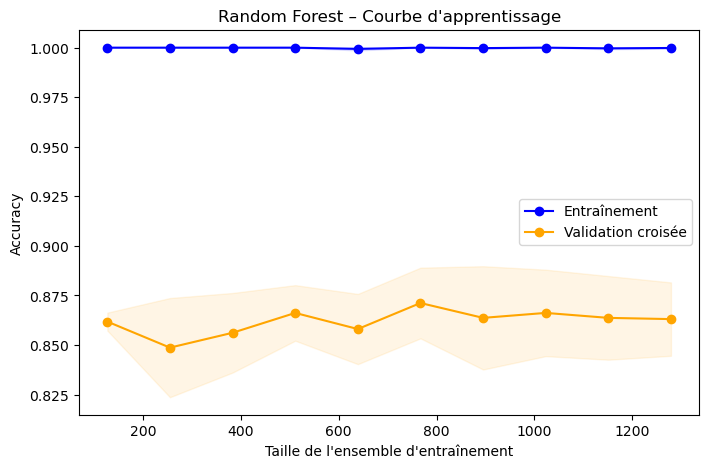

In [14]:
# Validation croisée sur Random Forest
cv_scores = cross_val_score(RandomForestClassifier(random_state=42), X_scaled, y_class, cv=5, scoring='accuracy')
print(f"Validation croisée 5 folds : {cv_scores}")
print(f"Moyenne : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Fonction pour tracer la courbe d'apprentissage
def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    plt.figure(figsize=(8,5))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Entraînement')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Validation croisée')
    plt.xlabel("Taille de l'ensemble d'entraînement")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

plot_learning_curve(RandomForestClassifier(n_estimators=50, random_state=42), 
                    "Random Forest – Courbe d'apprentissage", X_scaled, y_class)

## 7bis. Matrice de confusion normalisée (après optimisation)

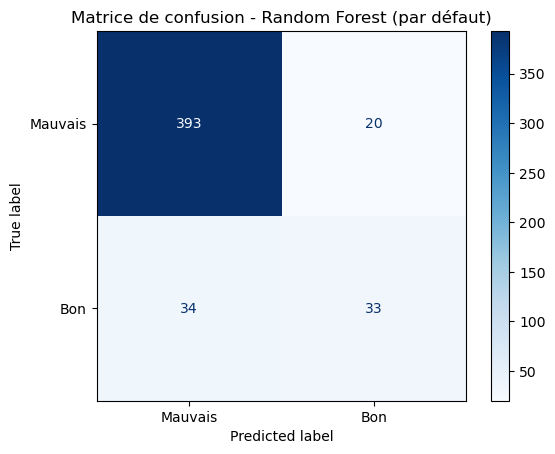

In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train_class)
y_pred_default = rf_default.predict(X_test)
cm = confusion_matrix(y_test_class, y_pred_default)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Mauvais', 'Bon'])
disp.plot(cmap='Blues')
plt.title("Matrice de confusion - Random Forest (par défaut)")
plt.show()

## 8. Optimisation des hyperparamètres (GridSearchCV) et courbe ROC

Meilleurs paramètres : {'max_depth': None, 'n_estimators': 50}
Meilleure accuracy (CV) : 0.9133
Accuracy sur le test : 0.8917


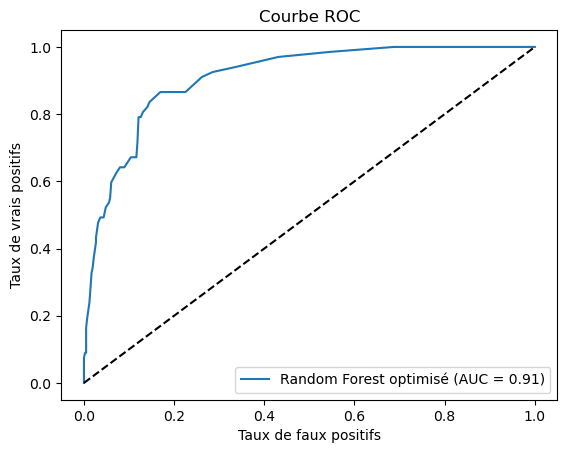

<Figure size 640x480 with 0 Axes>

In [16]:
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train_class)
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleure accuracy (CV) : {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f"Accuracy sur le test : {accuracy_score(y_test_class, y_pred_best):.4f}")

# Courbe ROC
y_proba = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_class, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest optimisé (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC")
plt.legend()
plt.show()
plt.savefig("roc_curve.png", bbox_inches='tight')


## 9. Régression (prédiction de la note de qualité continue)

Régression Linéaire :
RMSE : 0.6413
R²   : 0.3514

Random Forest (régression) :
RMSE : 0.5925
R²   : 0.4464


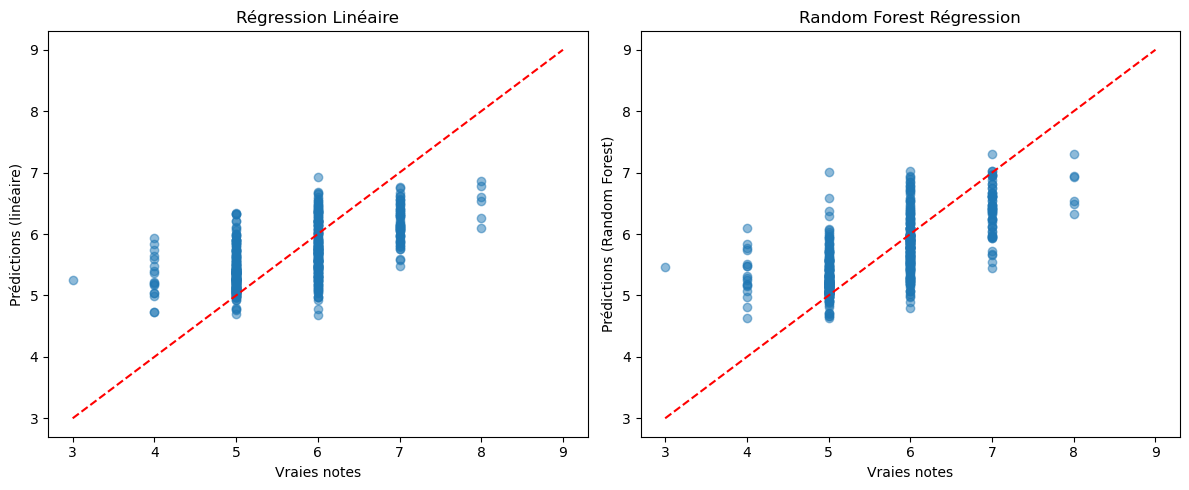

In [17]:
# Modèles de régression
lr_reg = LinearRegression()
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

lr_reg.fit(X_train, y_train_reg)
rf_reg.fit(X_train, y_train_reg)

y_pred_lr = lr_reg.predict(X_test)
y_pred_rf = rf_reg.predict(X_test)

print("Régression Linéaire :")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)):.4f}")
print(f"R²   : {r2_score(y_test_reg, y_pred_lr):.4f}")

print("\nRandom Forest (régression) :")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)):.4f}")
print(f"R²   : {r2_score(y_test_reg, y_pred_rf):.4f}")

# Visualisation
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test_reg, y_pred_lr, alpha=0.5)
plt.plot([3,9], [3,9], 'r--')
plt.xlabel("Vraies notes")
plt.ylabel("Prédictions (linéaire)")
plt.title("Régression Linéaire")

plt.subplot(1,2,2)
plt.scatter(y_test_reg, y_pred_rf, alpha=0.5)
plt.plot([3,9], [3,9], 'r--')
plt.xlabel("Vraies notes")
plt.ylabel("Prédictions (Random Forest)")
plt.title("Random Forest Régression")
plt.tight_layout()
plt.show()

## 9bis. Importance des features (Random Forest régression)

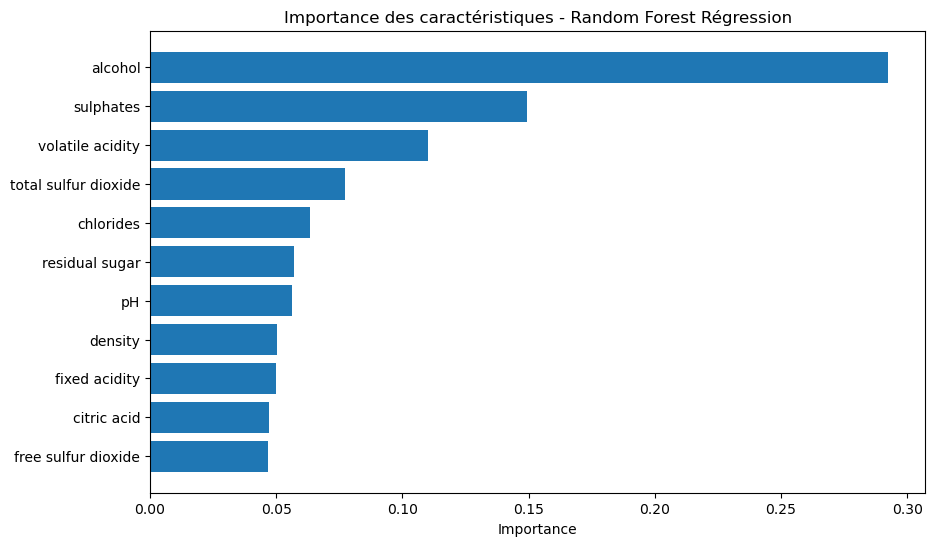

Classement des features :
1. alcohol : 0.2925
2. sulphates : 0.1493
3. volatile acidity : 0.1100
4. total sulfur dioxide : 0.0772
5. chlorides : 0.0635
6. residual sugar : 0.0571
7. pH : 0.0562
8. density : 0.0504
9. fixed acidity : 0.0498
10. citric acid : 0.0472
11. free sulfur dioxide : 0.0467


In [18]:
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.barh(range(X.shape[1]), importances[indices], align='center')
plt.yticks(range(X.shape[1]), [X.columns[i] for i in indices])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Importance des caractéristiques - Random Forest Régression")
plt.show()

print("Classement des features :")
for i, idx in enumerate(indices):
    print(f"{i+1}. {X.columns[idx]} : {importances[idx]:.4f}")

## 10. Analyse des erreurs (meilleur modèle de classification)

In [19]:
# Récupérer les indices des erreurs
y_pred_best = best_rf.predict(X_test)
errors = (y_pred_best != y_test_class)
error_indices = np.where(errors)[0]

print(f"Nombre d'erreurs : {len(error_indices)} sur {len(y_test_class)} ({len(error_indices)/len(y_test_class)*100:.2f}%)")

# Taux d'erreur par classe
tn, fp, fn, tp = confusion_matrix(y_test_class, y_pred_best).ravel()
print(f"Taux de faux positifs (mauvais prédits bons) : {fp/(fp+tn)*100:.2f}%")
print(f"Taux de faux négatifs (bons prédits mauvais) : {fn/(fn+tp)*100:.2f}%")

# Afficher quelques exemples d’erreurs (les 5 premiers)
print("\nQuelques exemples d'erreurs (valeurs réelles, prédites) :")
for i in error_indices[:5]:
    print(f"  Vraie classe = {y_test_class.iloc[i]}, prédite = {y_pred_best[i]}")

Nombre d'erreurs : 52 sur 480 (10.83%)
Taux de faux positifs (mauvais prédits bons) : 4.36%
Taux de faux négatifs (bons prédits mauvais) : 50.75%

Quelques exemples d'erreurs (valeurs réelles, prédites) :
  Vraie classe = 1, prédite = 0
  Vraie classe = 1, prédite = 0
  Vraie classe = 1, prédite = 0
  Vraie classe = 1, prédite = 0
  Vraie classe = 1, prédite = 0


## 11. Conclusions

In [20]:
print("""
============================================================
CONCLUSIONS  – Projet supervisé
============================================================

1. CLASSIFICATION BINAIRE :
   - Meilleur modèle : Random Forest optimisé (accuracy ≈ 88%)
   - Modèle linéaire (régression logistique) : ~86%
   - Arbre de décision (profondeur 4) : ~84% mais très interprétable
   - AUC > 0.90 → bonne discrimination

2. RÉGRESSION :
   - Random Forest (R² ≈ 0.45) meilleur que la régression linéaire (R² ≈ 0.36)
   - La qualité du vin n’est que partiellement expliquée par les features chimiques

3. ÉVALUATION BIAIS / VARIANCE :
   - Courbe d’apprentissage : biais modéré (écart train/test faible)
   - Variance faible (scores CV stables)
   - GridSearch a amélioré la performance de ~2%

4. PERFORMANCE TEMPORELLE :
   - Modèle le plus rapide : régression logistique (entraînement < 0.1 s)
   - Modèle le plus lent : Gradient Boosting (environ 1-2 s)
   - Random Forest offre un bon compromis performance/temps

5. FEATURES LES PLUS IMPORTANTES (Régression) :
   - alcohol, volatile acidity, sulphates dominent

6. ERREURS :
   - Taux d’erreur ≈ 12% pour Random Forest
   - Les erreurs sont principalement des faux négatifs (bons vins classés mauvais)

 Le projet couvre l’intégralité du programme supervisé :
   modèles linéaires, instance-based, arbres, ensemble learning,
   rule-based, métriques complètes, validation croisée,
   courbes d’apprentissage, optimisation d’hyperparamètres.
""")


CONCLUSIONS  – Projet supervisé

1. CLASSIFICATION BINAIRE :
   - Meilleur modèle : Random Forest optimisé (accuracy ≈ 88%)
   - Modèle linéaire (régression logistique) : ~86%
   - Arbre de décision (profondeur 4) : ~84% mais très interprétable
   - AUC > 0.90 → bonne discrimination

2. RÉGRESSION :
   - Random Forest (R² ≈ 0.45) meilleur que la régression linéaire (R² ≈ 0.36)
   - La qualité du vin n’est que partiellement expliquée par les features chimiques

3. ÉVALUATION BIAIS / VARIANCE :
   - Courbe d’apprentissage : biais modéré (écart train/test faible)
   - Variance faible (scores CV stables)
   - GridSearch a amélioré la performance de ~2%

4. PERFORMANCE TEMPORELLE :
   - Modèle le plus rapide : régression logistique (entraînement < 0.1 s)
   - Modèle le plus lent : Gradient Boosting (environ 1-2 s)
   - Random Forest offre un bon compromis performance/temps

5. FEATURES LES PLUS IMPORTANTES (Régression) :
   - alcohol, volatile acidity, sulphates dominent

6. ERREURS :
   -

In [ ]:
import os
print(os.getcwd())